Licensed under the Apache License, Version 2.0

In [ ]:
# @title Imports
import collections

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rc('font', family='serif', size=12)
import matplotlib.style as style
style.use('tableau-colorblind10')

In [ ]:
CSV_PATH = ''  # Update to the CSV path.

In [ ]:
with open(CSV_PATH, 'r') as f:
  df = pd.read_csv(f, index_col=False)

In [ ]:
df

,Unnamed: 0,flight_id,passes_level1,passes_level2,passes_level3,treatment,aircraft_type,distance_in_observation_region,observed_contrail_km,observed_warming,forecast_warming_flown_plan,forecast_contrail_distance_flown_plan,forecast_warming_min_cost_plan,forecast_contrail_distance_min_cost_plan
0,0,id-2936118109869803532,True,False,False,True,B788,4285.847999,738.897720,9.458656e+10,20.966164,499.174239,21.086136,500.680150
1,1,id-1744163191043755980,True,False,False,True,B788,3578.838113,166.150602,3.567239e+10,22.751840,350.973560,21.890886,328.373921
2,2,id-4616528403613142621,True,False,False,True,B789,3571.697525,123.989708,1.402373e+10,18.919766,348.913406,19.034787,340.035220
3,3,id-4939982033107030169,True,False,False,True,B772,5319.830393,284.844278,5.391966e+10,24.585653,434.597299,11.507246,186.256823
4,4,id-7344910409671412605,True,False,False,True,B788,4145.928913,0.000000,0.000000e+00,5.183814,250.757250,6.724942,279.632105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2358,2358,id-1035545674337476875,True,False,False,False,B772,6868.949653,0.000000,0.000000e+00,2.820676,59.837016,NaN,NaN
2359,2359,id-4246372569875478655,True,False,False,False,B772,5013.257791,0.000000,0.000000e+00,9.893351,138.137727,NaN,NaN
2360,2360,id3775451088063331500,True,False,False,False,B772,3400.033879,599.050771,7.492293e+10,11.236440,294.702834,NaN,NaN
2361,2361,id-1932687407080770350,True,False,False,False,B788,4311.158701,833.939727,8.290038e+10,10.394805,362.025361,NaN,NaN


# Analysis with Aircraft Type Correction

In [ ]:
def run_stratified_analysis(control_df, treatment_df, val_col, len_col, strata_col='aircraft_type', n_perms=10_000, n_bootstraps=10_000, alternative='greater'):
    """
    Runs a complete Stratified Analysis:
    1. Stratified Permutation Test -> Returns P-value (Significance)
    2. Stratified Bootstrap -> Returns 95% CI (Effect Size Uncertainty)
    """

    # --- 1. SETUP & OBSERVED STATISTIC ---
    control_df = control_df.copy()
    treatment_df = treatment_df.copy()
    control_df['treatment'] = control_df['treatment'].astype(int)
    treatment_df['treatment'] = treatment_df['treatment'].astype(int)

    pooled_df = pd.concat([control_df, treatment_df]).reset_index(drop=True)
    target_weights = pooled_df[strata_col].value_counts(normalize=True)

    # 1. Calculate Row-Level Rate for plotting
    pooled_df['row_rate'] = np.where(pooled_df[len_col] > 0,
                                     pooled_df[val_col] / pooled_df[len_col],
                                     0)

    # 2. Calculate Weights to adjust for Strata Imbalance
    ctrl_props = control_df[strata_col].value_counts(normalize=True)
    trt_props = treatment_df[strata_col].value_counts(normalize=True)

    def get_viz_weight(row):
        s = row[strata_col]
        if row['treatment'] == 1:
            return target_weights.get(s, 0) / trt_props.get(s, 1)
        else:
            return target_weights.get(s, 0) / ctrl_props.get(s, 1)

    pooled_df['viz_weight'] = pooled_df.apply(get_viz_weight, axis=1)

    # Pre-Optimization Arrays
    vals = pooled_df[val_col].values
    lens = pooled_df[len_col].values
    strata = pooled_df[strata_col].values
    original_labels = pooled_df['treatment'].values

    unique_strata = np.unique(strata)
    strata_indices = {s: np.where(strata == s)[0] for s in unique_strata}

    # Calculate Observed Statistic
    obs_trt_rate = 0.0
    obs_ctrl_rate = 0.0

    for s, idxs in strata_indices.items():
        w_k = target_weights[s]
        subset_labels = original_labels[idxs]

        # Treatment
        is_t = (subset_labels == 1)
        # Check if we have data (avoid div by zero)
        if np.sum(is_t) > 0:
            sum_y_t = np.sum(vals[idxs][is_t])
            sum_l_t = np.sum(lens[idxs][is_t])
            if sum_l_t > 0: obs_trt_rate += w_k * (sum_y_t / sum_l_t)

        # Control
        is_c = (subset_labels == 0)
        if np.sum(is_c) > 0:
            sum_y_c = np.sum(vals[idxs][is_c])
            sum_l_c = np.sum(lens[idxs][is_c])
            if sum_l_c > 0: obs_ctrl_rate += w_k * (sum_y_c / sum_l_c)

    obs_stat = 1.0 - (obs_trt_rate / obs_ctrl_rate)
    print(f"Observed Stratified Reduction: {obs_stat:.4%}")

    # ==========================================================
    # PART A: PERMUTATION TEST (For P-Value)
    # Logic: Shuffle labels WITHIN strata
    # ==========================================================
    null_stats = np.zeros(n_perms)

    for i in range(n_perms):
        perm_trt_rate = 0.0
        perm_ctrl_rate = 0.0

        for s, idxs in strata_indices.items():
            w_k = target_weights[s]
            current_labels = original_labels[idxs]
            np.random.shuffle(current_labels) # Shuffle Labels

            # Pseudo-Treatment
            is_t = (current_labels == 1)
            if np.sum(is_t) > 0:
                v_s = vals[idxs]
                l_s = lens[idxs]
                r_t = np.sum(v_s[is_t]) / np.sum(l_s[is_t])
                perm_trt_rate += w_k * r_t

            # Pseudo-Control
            is_c = (current_labels == 0)
            if np.sum(is_c) > 0:
                v_s = vals[idxs]
                l_s = lens[idxs]
                r_c = np.sum(v_s[is_c]) / np.sum(l_s[is_c])
                perm_ctrl_rate += w_k * r_c

        if perm_ctrl_rate > 0:
            null_stats[i] = 1.0 - (perm_trt_rate / perm_ctrl_rate)
        else:
            null_stats[i] = 0

    # P-Value Calculation
    if alternative == 'two-sided':
        p_value = np.mean(np.abs(null_stats) >= np.abs(obs_stat))
    elif alternative == 'greater':
        p_value = np.mean(null_stats >= obs_stat)
    elif alternative == 'less':
        p_value = np.mean(null_stats <= obs_stat)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    # ==========================================================
    # PART B: BOOTSTRAP (For Confidence Interval)
    # Logic: Resample Data with Replacement WITHIN strata
    # ==========================================================
    boot_stats = np.zeros(n_bootstraps)

    # Pre-separate indices for bootstrapping to make sampling easier
    # dict: {'A320': {'trt': [indices], 'ctrl': [indices]}}
    boot_indices = {}
    for s, idxs in strata_indices.items():
        subset_labels = original_labels[idxs]
        boot_indices[s] = {
            'trt': idxs[subset_labels == 1],
            'ctrl': idxs[subset_labels == 0]
        }

    for i in range(n_bootstraps):
        boot_trt_rate = 0.0
        boot_ctrl_rate = 0.0

        for s in unique_strata:
            w_k = target_weights[s]

            # --- Resample Treatment ---
            # Indices for Treatment in this stratum
            idx_t = boot_indices[s]['trt']
            n_t = len(idx_t)
            if n_t > 0:
                # Random choice of indices WITH replacement
                resampled_idx_t = np.random.choice(idx_t, size=n_t, replace=True)
                r_t = np.sum(vals[resampled_idx_t]) / np.sum(lens[resampled_idx_t])
                boot_trt_rate += w_k * r_t

            # --- Resample Control ---
            idx_c = boot_indices[s]['ctrl']
            n_c = len(idx_c)
            if n_c > 0:
                resampled_idx_c = np.random.choice(idx_c, size=n_c, replace=True)
                r_c = np.sum(vals[resampled_idx_c]) / np.sum(lens[resampled_idx_c])
                boot_ctrl_rate += w_k * r_c

        if boot_ctrl_rate > 0:
            boot_stats[i] = 1.0 - (boot_trt_rate / boot_ctrl_rate)
        else:
            boot_stats[i] = np.nan # Should not happen with large N

    # CI Calculation (Percentile Method)
    ci_lower = np.nanpercentile(boot_stats, 2.5)
    ci_upper = np.nanpercentile(boot_stats, 97.5)

    return {
        'obs_stat': obs_stat,
        'p_value': p_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'null_stats': null_stats,
        'boot_stats': boot_stats,
        'plot_data': pooled_df
    }

def pretty_print_stratified(results):
  print(f'p-value: {results["p_value"]} -> {"Significant" if results["p_value"] < 0.05 else "Not Significant"}')
  print(f'95% CI: [{results["ci_lower"]*100:.4f}%, {results["ci_upper"]*100:.4f}%]')

In [ ]:
print('Contrail Distance Analysis')
print()

for test_level in ['passes_level1', 'passes_level2', 'passes_level3']:
  print(f'=========== Analysis for {test_level} ===========')
  results = run_stratified_analysis(
      control_df=df[~df.treatment],
      treatment_df=df[df.treatment & df[test_level]],
      val_col='observed_contrail_km',
      len_col='distance_in_observation_region',
      strata_col='aircraft_type',
      alternative='greater'
  )
  pretty_print_stratified(results)
  print('==================================================')
  print()

Contrail Distance Analysis

=========== Analysis for passes_level1 ===========
Observed Stratified Reduction: 11.6060%
p-value: 0.0111 -> Significant
95% CI: [2.0997%, 20.3844%]

=========== Analysis for passes_level2 ===========
Observed Stratified Reduction: 29.4864%
p-value: 0.0012 -> Significant
95% CI: [11.1015%, 46.3473%]

=========== Analysis for passes_level3 ===========
Observed Stratified Reduction: 61.9977%
p-value: 0.0 -> Significant
95% CI: [46.8348%, 75.2310%]



In [ ]:
print('Climatology Analysis')
print()

for test_level in ['passes_level1', 'passes_level2', 'passes_level3']:
  print(f'=========== Analysis for {test_level} ===========')
  results = run_stratified_analysis(
      control_df=df[~df.treatment],
      treatment_df=df[df.treatment & df[test_level]],
      val_col='observed_warming',
      len_col='distance_in_observation_region',
      strata_col='aircraft_type',
      alternative='greater'
  )
  pretty_print_stratified(results)
  print('==================================================')
  print()

Climatology Analysis

=========== Analysis for passes_level1 ===========
Observed Stratified Reduction: 13.6908%
p-value: 0.0067 -> Significant
95% CI: [2.9590%, 23.4281%]

=========== Analysis for passes_level2 ===========
Observed Stratified Reduction: 35.4754%
p-value: 0.0002 -> Significant
95% CI: [18.9297%, 50.1649%]

=========== Analysis for passes_level3 ===========
Observed Stratified Reduction: 69.2688%
p-value: 0.0 -> Significant
95% CI: [55.8161%, 80.5035%]



## Plots

/tmp/ipykernel_25913/888988508.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


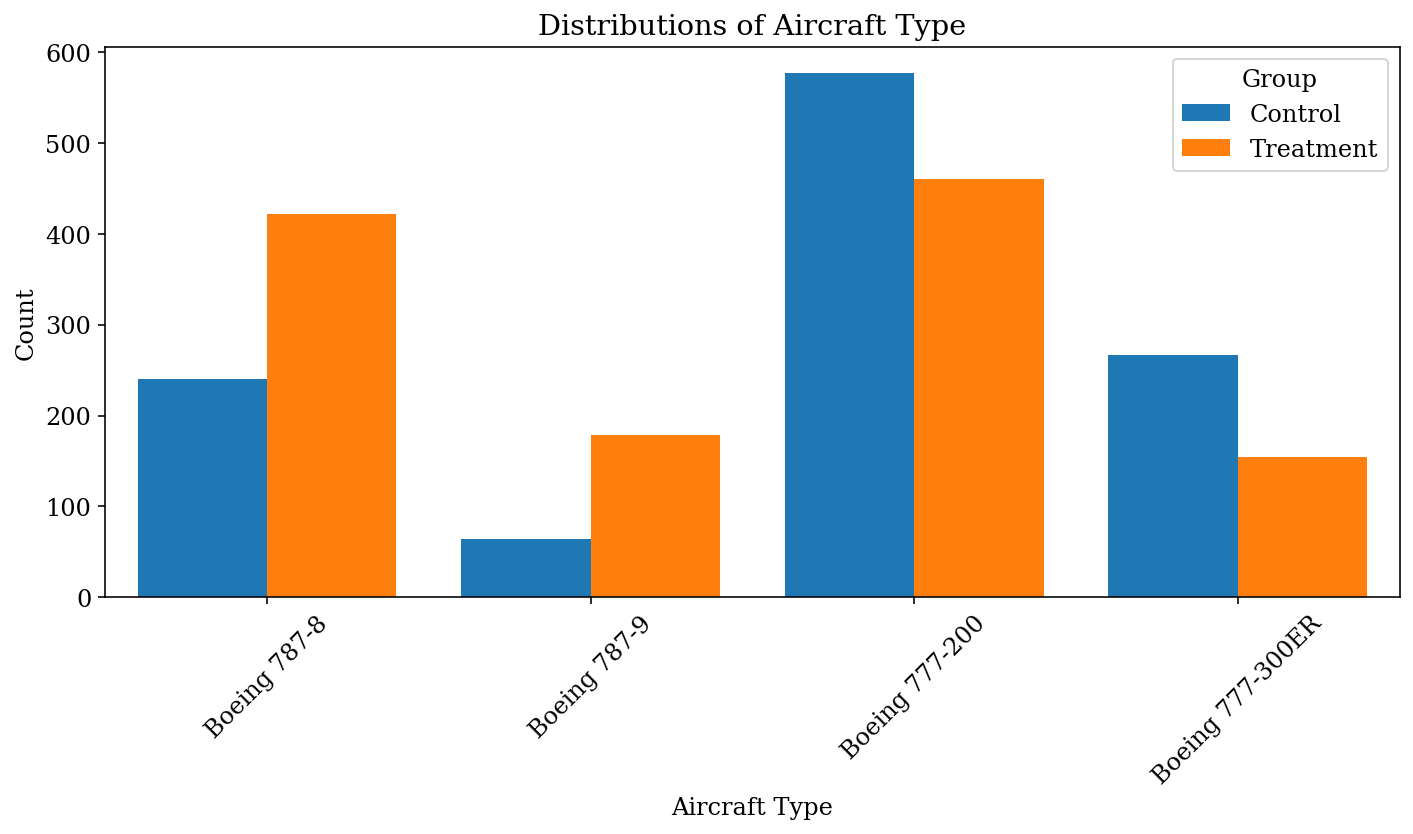

In [ ]:
# 2. Define your mapping dictionary
type_mapping = {
    'B788': 'Boeing 787-8',
    'B789': 'Boeing 787-9',
    'B772': 'Boeing 777-200',
    'B77W': 'Boeing 777-300ER'
}

# 3. Create the Plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='aircraft_type', hue='treatment', palette='tab10', saturation=1)

# 4. Map the tick labels
# We grab the existing labels first to ensure we map the correct bar to the correct name
current_labels = [item.get_text() for item in ax.get_xticklabels()]
new_labels = [type_mapping.get(label, label) for label in current_labels]

ax.set_xticklabels(new_labels)

# 5. Final Formatting
plt.title('Distributions of Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Count')
plt.legend(title='Group', labels=['Control', 'Treatment'])
plt.xticks(rotation=45) # Rotate labels for better readability

plt.tight_layout()
plt.show()

# Analysis without Aircraft Type Correction

In [ ]:
def bootstrap_reduction(control_df, treatment_df, val_key, length_key):
  n_boostraps = 1000
  reductions = []
  treatment_vals = []
  control_vals = []
  for _ in range(n_boostraps):
    control_sample = control_df.sample(frac=1, replace=True)
    treatment_sample = treatment_df.sample(frac=1, replace=True)
    match_km_fraction_treatment = np.sum(treatment_sample[val_key])/np.sum(treatment_sample[length_key])
    match_km_fraction_control = np.sum(control_sample[val_key])/np.sum(control_sample[length_key])
    treatment_vals.append(match_km_fraction_treatment)
    control_vals.append(match_km_fraction_control)
    reductions.append(match_km_fraction_treatment/match_km_fraction_control)
  return {
      'control_mean': np.mean(control_vals),
      'control_upper': np.percentile(control_vals, 97.5),
      'control_lower': np.percentile(control_vals, 2.5),
      'treatment_mean': np.mean(treatment_vals),
      'treatment_upper': np.percentile(treatment_vals, 97.5),
      'treatment_lower': np.percentile(treatment_vals, 2.5),
      'reduction_mean': np.mean(reductions),
      'reduction_upper': np.percentile(reductions, 97.5),
      'reduction_lower': np.percentile(reductions, 2.5),
      }

def pretty_print_bootstrap(bootstrap_results):
  print(f'control: {bootstrap_results["control_mean"]:.3f} ({bootstrap_results["control_lower"]:.3f}-{bootstrap_results["control_upper"]:.3f})')
  print(f'treatment: {bootstrap_results["treatment_mean"]:.3f} ({bootstrap_results["treatment_lower"]:.3f}-{bootstrap_results["treatment_upper"]:.3f})')
  print(f'reduction: {1-bootstrap_results["reduction_mean"]:.3f} ({1-bootstrap_results["reduction_upper"]:.3f}-{1-bootstrap_results["reduction_lower"]:.3f})')

def print_all_results(val, length, outliers=[]):
  print(val)
  print('-----L1-----')
  match_results_l1 = bootstrap_reduction(df[~df.treatment], df[df.treatment],val, length)
  pretty_print_bootstrap(match_results_l1)
  print('-----L2-----')
  match_results_l1 = bootstrap_reduction(df[~df.treatment], df[df.treatment & df.passes_level2],val, length)
  pretty_print_bootstrap(match_results_l1)
  print('-----L3-----')
  match_results_l1 = bootstrap_reduction(df[~df.treatment], df[df.treatment  & df.passes_level3],val, length)
  pretty_print_bootstrap(match_results_l1)

In [ ]:
print_all_results('observed_contrail_km', 'distance_in_observation_region')

observed_contrail_km
-----L1-----
control: 0.060 (0.055-0.064)
treatment: 0.053 (0.049-0.057)
reduction: 0.115 (0.019-0.199)
-----L2-----
control: 0.060 (0.055-0.064)
treatment: 0.038 (0.031-0.046)
reduction: 0.357 (0.219-0.483)
-----L3-----
control: 0.060 (0.055-0.064)
treatment: 0.021 (0.015-0.028)
reduction: 0.645 (0.519-0.752)


In [ ]:
print_all_results('observed_warming', 'distance_in_observation_region')

observed_warming
-----L1-----
control: 9213309.044 (8530048.250-9968181.935)
treatment: 7931574.422 (7294937.879-8523938.101)
reduction: 0.138 (0.040-0.226)
-----L2-----
control: 9202622.494 (8467193.668-9971919.552)
treatment: 5793290.303 (4565510.774-7174654.491)
reduction: 0.369 (0.212-0.511)
-----L3-----
control: 9217518.329 (8458694.139-9987030.207)
treatment: 2817045.373 (1817462.272-3904267.143)
reduction: 0.694 (0.572-0.804)


# Counterfactual Analysis

## Forecast Calibration

In [ ]:
bootstrap_vals = collections.defaultdict(list)
nonnan_df = df[~df.forecast_contrail_distance_flown_plan.isna()]
for _ in range(100):
  boot_df = nonnan_df.sample(len(nonnan_df), replace=True)
  tdf = boot_df[~boot_df.treatment]
  bootstrap_vals['match_per_km_control'].append(tdf.observed_contrail_km.sum() / tdf.distance_in_observation_region.sum())
  bootstrap_vals['flown_contrail_distance_control'].append(tdf.forecast_contrail_distance_flown_plan.sum() / tdf.distance_in_observation_region.sum())
  tdf = boot_df[boot_df.treatment & boot_df.passes_level1]
  bootstrap_vals['match_per_km_L1'].append(tdf.observed_contrail_km.sum() / tdf.distance_in_observation_region.sum())
  bootstrap_vals['flown_contrail_distance_L1'].append(tdf.forecast_contrail_distance_flown_plan.sum() / tdf.distance_in_observation_region.sum())
  tdf = boot_df[boot_df.treatment & boot_df.passes_level2]
  bootstrap_vals['match_per_km_L2'].append(tdf.observed_contrail_km.sum() / tdf.distance_in_observation_region.sum())
  bootstrap_vals['flown_contrail_distance_L2'].append(tdf.forecast_contrail_distance_flown_plan.sum() / tdf.distance_in_observation_region.sum())
  tdf = boot_df[boot_df.treatment & boot_df.passes_level3]
  bootstrap_vals['match_per_km_L3'].append(tdf.observed_contrail_km.sum() / tdf.distance_in_observation_region.sum())
  bootstrap_vals['flown_contrail_distance_L3'].append(tdf.forecast_contrail_distance_flown_plan.sum() / tdf.distance_in_observation_region.sum())

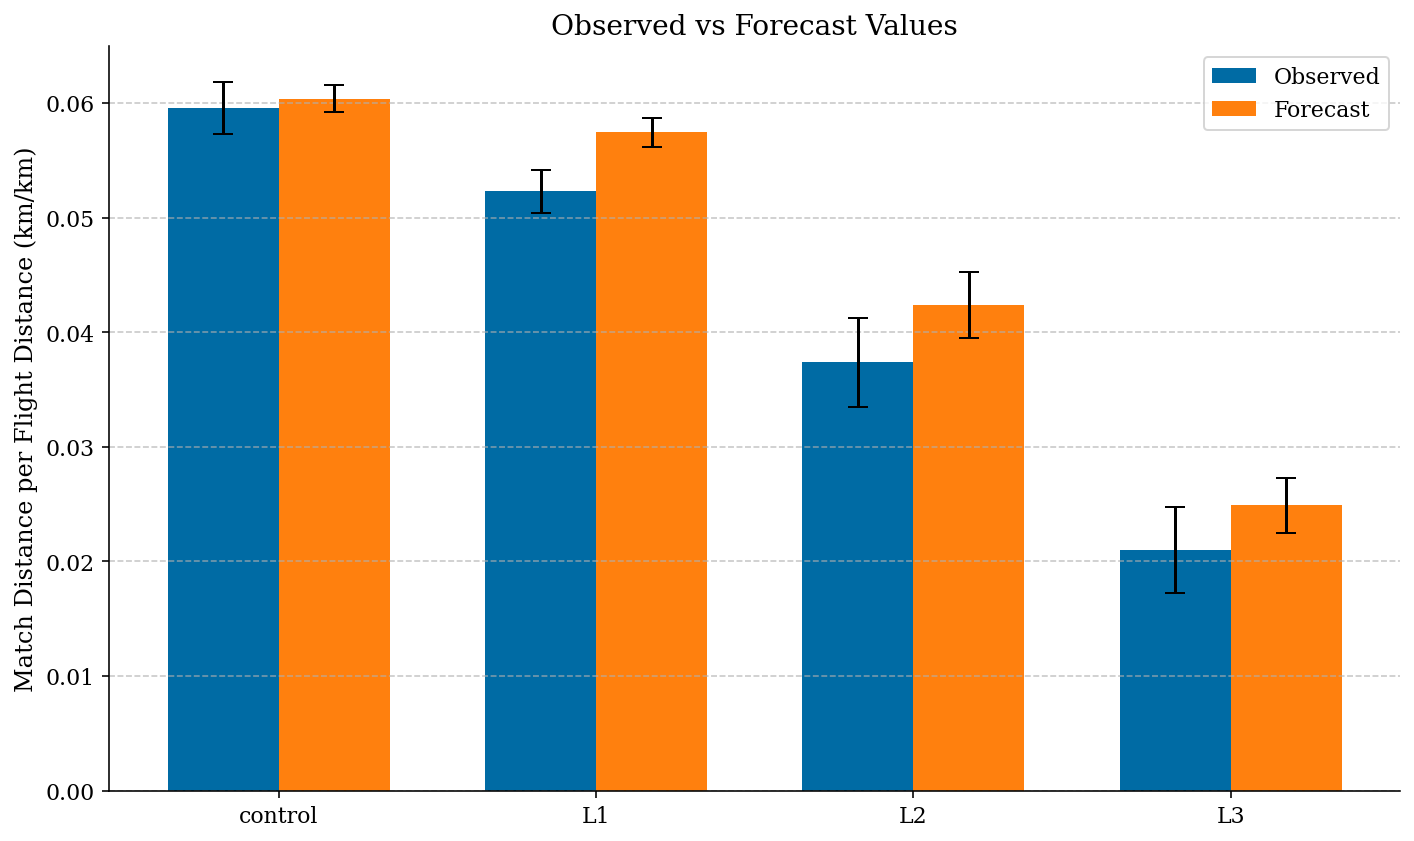

In [ ]:
xs = np.arange(4)
xlabels = ['control', 'L1', 'L2', 'L3']

obs_means = [np.mean(bootstrap_vals[f'match_per_km_{label}']) for label in xlabels]
obs_stds = [np.std(bootstrap_vals[f'match_per_km_{label}']) for label in xlabels]

fc_means = [np.mean(bootstrap_vals[f'flown_contrail_distance_{label}']) for label in xlabels]
fc_stds = [np.std(bootstrap_vals[f'flown_contrail_distance_{label}']) for label in xlabels]

plt.figure(figsize=(10, 6))
width = 0.35

# Removed specific color arguments to let Matplotlib use defaults (Blue/Orange)
plt.bar(xs - width/2, obs_means, width, yerr=obs_stds, label='Observed', capsize=5)
plt.bar(xs + width/2, fc_means, width, yerr=fc_stds, label='Forecast', capsize=5)

plt.ylabel('Match Distance per Flight Distance (km/km)', fontsize=12)
plt.title('Observed vs Forecast Values', fontsize=14)
plt.xticks(xs, xlabels, fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Counterfactual Reductions

In [ ]:
import numpy as np
import pandas as pd

def run_global_analysis(control_df, treatment_df, val_col, len_col, n_perms=10_000, n_bootstraps=10_000, alternative='greater'):
    """
    Runs a simplified Global Analysis (No Stratification):
    1. Global Permutation Test -> Returns P-value (Significance)
    2. Global Bootstrap -> Returns 95% CI (Effect Size Uncertainty)
    """

    # --- 1. SETUP & OBSERVED STATISTIC ---
    control_df = control_df.copy()
    treatment_df = treatment_df.copy()

    # Force treatment labels for global analysis
    control_df['treatment'] = 0
    treatment_df['treatment'] = 1

    pooled_df = pd.concat([control_df, treatment_df]).reset_index(drop=True)

    # 1. Calculate Row-Level Rate for plotting
    pooled_df['row_rate'] = np.where(pooled_df[len_col] > 0,
                                     pooled_df[val_col] / pooled_df[len_col],
                                     0)

    # Viz weight is just 1.0 since there is no strata re-weighting
    pooled_df['viz_weight'] = 1.0

    # Optimization Arrays
    vals = pooled_df[val_col].values
    lens = pooled_df[len_col].values
    original_labels = pooled_df['treatment'].values

    # Calculate Global Observed Statistic
    # Treatment Rate
    is_t = (original_labels == 1)
    sum_y_t = np.sum(vals[is_t])
    sum_l_t = np.sum(lens[is_t])
    obs_trt_rate = sum_y_t / sum_l_t if sum_l_t > 0 else 0.0

    # Control Rate
    is_c = (original_labels == 0)
    sum_y_c = np.sum(vals[is_c])
    sum_l_c = np.sum(lens[is_c])
    obs_ctrl_rate = sum_y_c / sum_l_c if sum_l_c > 0 else 0.0

    # Avoid div by zero
    if obs_ctrl_rate > 0:
        obs_stat = 1.0 - (obs_trt_rate / obs_ctrl_rate)
    else:
        obs_stat = 0.0

    print(f"Observed Global Reduction: {obs_stat:.4%}")

    # ==========================================================
    # PART A: GLOBAL PERMUTATION TEST (For P-Value)
    # Logic: Shuffle labels globally across the entire dataset
    # ==========================================================
    null_stats = np.zeros(n_perms)
    shuffled_labels = original_labels.copy()

    for i in range(n_perms):
        np.random.shuffle(shuffled_labels) # Global Shuffle

        # Pseudo-Treatment
        is_t = (shuffled_labels == 1)
        # Note: Using boolean masking on numpy arrays is efficient
        perm_trt_rate = 0.0
        if np.sum(is_t) > 0:
             perm_trt_rate = np.sum(vals[is_t]) / np.sum(lens[is_t])

        # Pseudo-Control
        is_c = (shuffled_labels == 0)
        perm_ctrl_rate = 0.0
        if np.sum(is_c) > 0:
            perm_ctrl_rate = np.sum(vals[is_c]) / np.sum(lens[is_c])

        if perm_ctrl_rate > 0:
            null_stats[i] = 1.0 - (perm_trt_rate / perm_ctrl_rate)
        else:
            null_stats[i] = 0

    # P-Value Calculation
    if alternative == 'two-sided':
        p_value = np.mean(np.abs(null_stats) >= np.abs(obs_stat))
    elif alternative == 'greater':
        p_value = np.mean(null_stats >= obs_stat)
    elif alternative == 'less':
        p_value = np.mean(null_stats <= obs_stat)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    # ==========================================================
    # PART B: GLOBAL BOOTSTRAP (For Confidence Interval)
    # Logic: Resample Data with Replacement within groups (Global Trt / Global Ctrl)
    # ==========================================================
    boot_stats = np.zeros(n_bootstraps)

    # Pre-calculate indices for global groups
    idx_t_global = np.where(original_labels == 1)[0]
    idx_c_global = np.where(original_labels == 0)[0]
    n_t = len(idx_t_global)
    n_c = len(idx_c_global)

    for i in range(n_bootstraps):

        # --- Resample Treatment ---
        if n_t > 0:
            res_idx_t = np.random.choice(idx_t_global, size=n_t, replace=True)
            boot_trt_rate = np.sum(vals[res_idx_t]) / np.sum(lens[res_idx_t])
        else:
            boot_trt_rate = 0.0

        # --- Resample Control ---
        if n_c > 0:
            res_idx_c = np.random.choice(idx_c_global, size=n_c, replace=True)
            boot_ctrl_rate = np.sum(vals[res_idx_c]) / np.sum(lens[res_idx_c])
        else:
            boot_ctrl_rate = 0.0

        if boot_ctrl_rate > 0:
            boot_stats[i] = 1.0 - (boot_trt_rate / boot_ctrl_rate)
        else:
            boot_stats[i] = np.nan

    # CI Calculation (Percentile Method)
    ci_lower = np.nanpercentile(boot_stats, 2.5)
    ci_upper = np.nanpercentile(boot_stats, 97.5)

    return {
        'obs_stat': obs_stat,
        'p_value': p_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'null_stats': null_stats,
        'boot_stats': boot_stats,
        'plot_data': pooled_df
    }

In [ ]:
for test_level in ['passes_level2', 'passes_level3']:
  print(f'=========== Analysis for {test_level} ===========')
  treatment_df = df[df[test_level]].dropna(subset=['forecast_contrail_distance_min_cost_plan']).copy()
  treatment_df['match_distance'] = treatment_df['forecast_contrail_distance_flown_plan']
  control_df = treatment_df.copy()
  control_df['match_distance'] = control_df['forecast_contrail_distance_min_cost_plan']

  counterfactual_distance_results = run_global_analysis(control_df=control_df,
                                                        treatment_df=treatment_df,
                                                        val_col='match_distance',
                                                        len_col='distance_in_observation_region')
  pretty_print_stratified(counterfactual_distance_results)
  print('==================================================')
  print()

=========== Analysis for passes_level2 ===========
Observed Global Reduction: 25.0235%
p-value: 0.0004 -> Significant
95% CI: [11.2716%, 36.5725%]

=========== Analysis for passes_level3 ===========
Observed Global Reduction: 49.2121%
p-value: 0.0 -> Significant
95% CI: [35.1081%, 60.6283%]

